<a href="https://colab.research.google.com/github/Swathi1-M/Real_Estate_Price_Prediction_Using_Hybrid_Models/blob/main/RealEstate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving AmesHousing.csv to AmesHousing.csv


In [ ]:
# Full ANN training with explicit Input for compatibility with Keras 3+

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import joblib

In [ ]:
import pandas as pd
df = pd.read_csv("/content/AmesHousing.csv")
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [ ]:
# 2. Select features and target
features = ['Gr Liv Area', 'Overall Qual', 'Year Built', 'Garage Cars', 'Total Bsmt SF']
target = 'SalePrice'
X = df[features]
y = df[target]

In [ ]:
# 3. Handle missing values
X.fillna(X.mean(), inplace=True)
y.fillna(y.mean(), inplace=True)

<ipython-input-6-897b4663cf80>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.fillna(X.mean(), inplace=True)


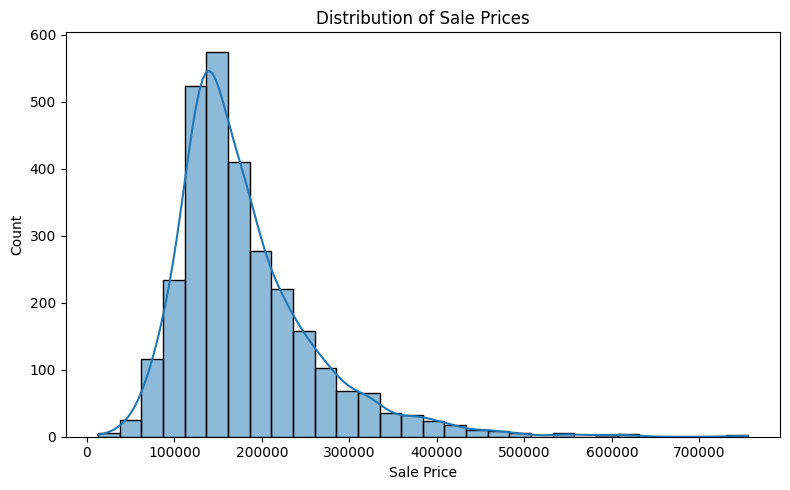

In [ ]:
# 4. Visualize distribution of Sale Prices
plt.figure(figsize=(8, 5))
sns.histplot(y, bins=30, kde=True)
plt.title("Distribution of Sale Prices")
plt.xlabel("Sale Price")
plt.tight_layout()
plt.show()

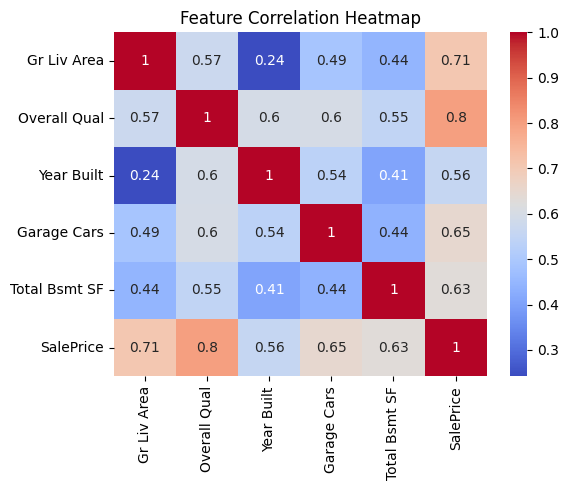

In [ ]:
# 5. Heatmap of Feature Correlation
plt.figure(figsize=(6, 5))
sns.heatmap(df[features + [target]].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

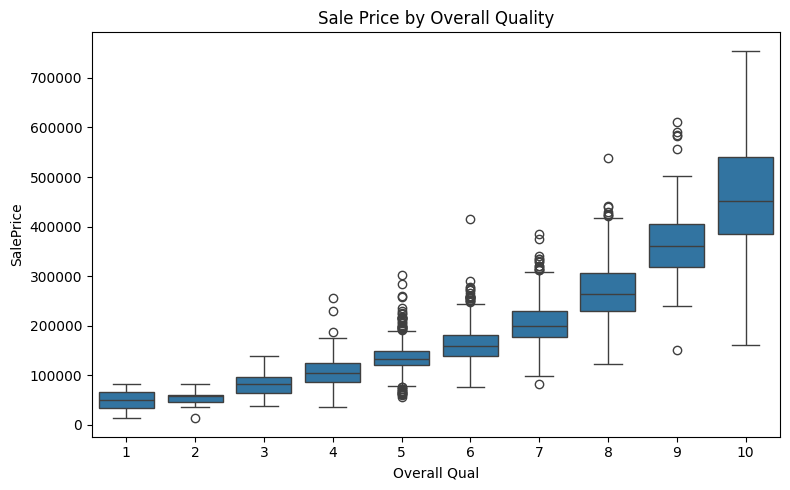

In [ ]:
# 6. Boxplot to detect outliers
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["Overall Qual"], y=df["SalePrice"])
plt.title("Sale Price by Overall Quality")
plt.tight_layout()
plt.show()

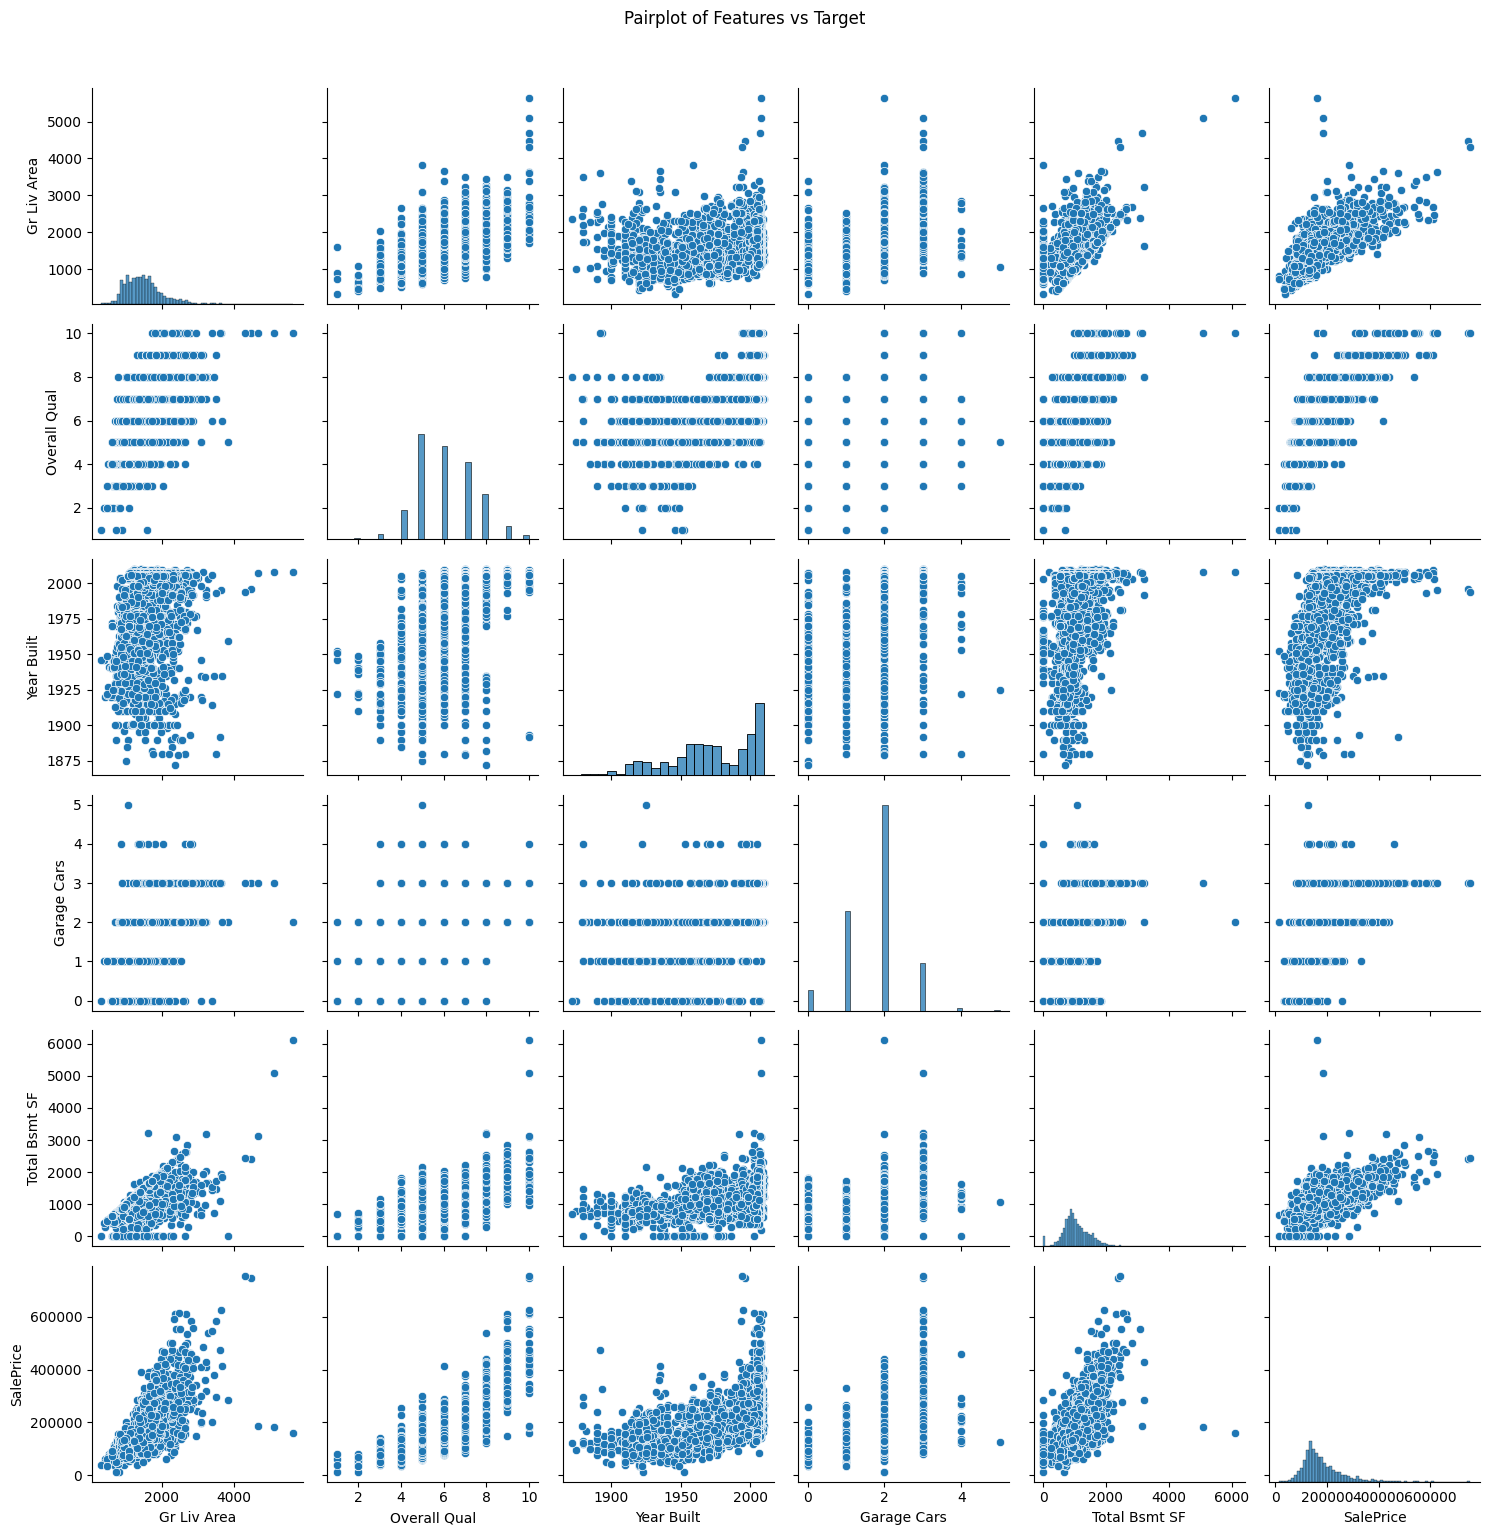

In [ ]:
# 7. Pairplot of selected features
sns.pairplot(df[features + [target]])
plt.suptitle("Pairplot of Features vs Target", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 5. Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Save scaler
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
# 6. Train XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train_scaled, y_train)
joblib.dump(xgb_model, "xgboost_model.pkl")

['xgboost_model.pkl']

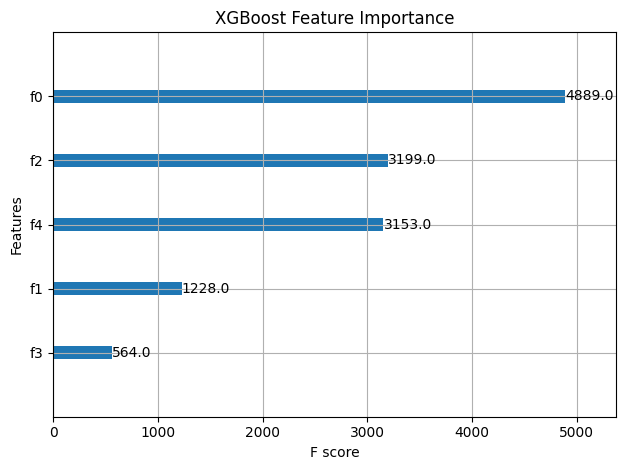

In [ ]:
# Plot feature importance
xgb.plot_importance(xgb_model)
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

In [ ]:
# 7. Train ANN with explicit Input layer
ann_model = Sequential([
    tf.keras.Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)
])
ann_model.compile(optimizer='adam', loss='mse')

ann_history = ann_model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_split=0.1)

Epoch 1/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 37522952192.0000 - val_loss: 36330094592.0000
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 39316312064.0000 - val_loss: 36310478848.0000
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 38046306304.0000 - val_loss: 36251697152.0000
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 37642530816.0000 - val_loss: 36127571968.0000
Epoch 5/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 37877542912.0000 - val_loss: 35914358784.0000
Epoch 6/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 37853552640.0000 - val_loss: 35590258688.0000
Epoch 7/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 37094793216.0000 - val_loss: 35134414848.0000
Epoch 8/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 36794257408.0000 - val_loss: 34535739392.0000
Epoch 9/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 36546793472.0000 - val_loss: 33785085952.0000
Epoch 10/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - l

In [ ]:
# Save properly for Keras 3+
ann_model.save("ann_model.keras")

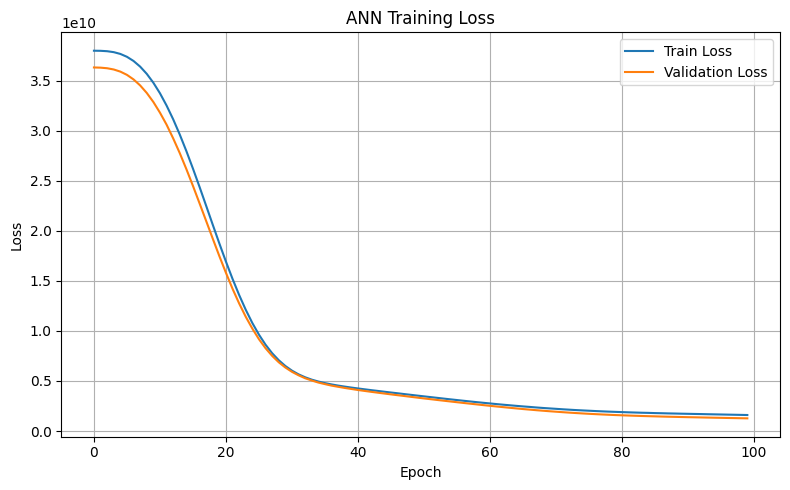

In [ ]:
# For ANN training loss
plt.figure(figsize=(8, 5))
plt.plot(ann_history.history['loss'], label='Train Loss')
plt.plot(ann_history.history['val_loss'], label='Validation Loss')
plt.title("ANN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# 8. Meta Model Ensemble
xgb_preds = xgb_model.predict(X_test_scaled)
ann_preds = ann_model.predict(X_test_scaled)

meta_X = np.column_stack((xgb_preds, ann_preds.flatten()))
meta_model = LinearRegression()
meta_model.fit(meta_X, y_test)
joblib.dump(meta_model, "meta_model.pkl")

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


['meta_model.pkl']

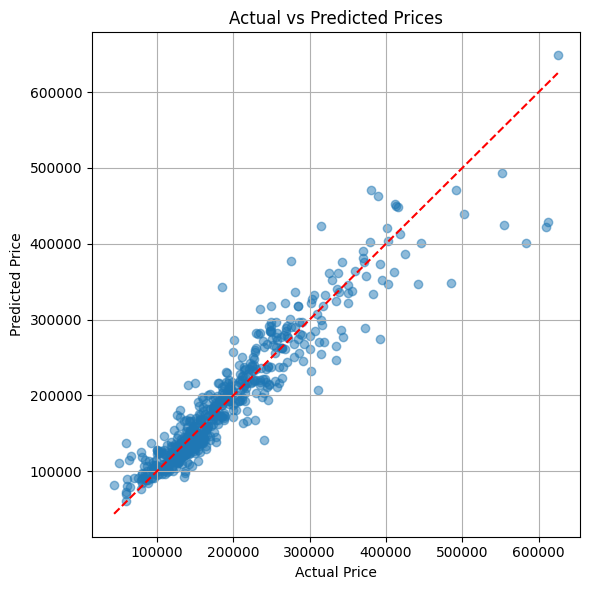

In [ ]:
# For Actual vs Predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test, final_preds, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Actual vs Predicted Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# 9. Evaluation
final_preds = meta_model.predict(meta_X)
r2 = r2_score(y_test, final_preds)
rmse = np.sqrt(mean_squared_error(y_test, final_preds))
print(f"R2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")

R2 Score: 0.8820
RMSE: 30763.94


In [ ]:
from google.colab import files

files.download("xgboost_model.pkl")
files.download("ann_model.keras")
files.download("meta_model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>